In [119]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot  as plt
import warnings

warnings.filterwarnings('ignore')

In [120]:
df =pd.read_csv('diabetes.csv')

In [121]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [122]:
df.shape

(768, 9)

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [124]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [125]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [126]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [127]:
for col in df.columns:
  zero_count = (df[col] == 0).sum()
  print(f"Count of zero on {col}: {zero_count}, percentage: {zero_count / len(df) * 100:.2f}%")
  print(60*"-")

Count of zero on Pregnancies: 111, percentage: 14.45%
------------------------------------------------------------
Count of zero on Glucose: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on BloodPressure: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on SkinThickness: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on Insulin: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on BMI: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on DiabetesPedigreeFunction: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on Age: 0, percentage: 0.00%
------------------------------------------------------------
Count of zero on Outcome: 500, percentage: 65.10%
----------------------------------------------------------

In [128]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [129]:
numeric_col =['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

In [130]:
outliers_summary =[]


for col in numeric_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR =Q3-Q1

    lower = Q1-(1.5*IQR)
    upper =Q3+(1.5* IQR)

    n_out = ((df[col]<lower)| (df[col]>upper)).sum()

    outliers_summary.append({
        'columns':col,
        'Outliers':n_out,
        'lower Bound':lower,
        'upper bound':upper
    })
out_df = pd.DataFrame(outliers_summary)
print("Total No of outliers = ",out_df['Outliers'].sum())

Total No of outliers =  202


In [131]:
print(out_df)

                    columns  Outliers  lower Bound  upper bound
0               Pregnancies         4        -6.50        13.50
1                   Glucose         0        39.00       201.00
2             BloodPressure        14        40.00       104.00
3             SkinThickness        87        14.50        42.50
4                   Insulin        51         2.00       270.00
5                       BMI         8        13.85        50.25
6  DiabetesPedigreeFunction        29        -0.33         1.20
7                       Age         9        -1.50        66.50


In [132]:
def clip_outliers_iqr(df, cols):
    df_clipped = df.copy()
    bounds = {}

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        bounds[col] = (lower, upper)

        df_clipped[col] = np.clip(df_clipped[col], lower, upper)

    return df_clipped, bounds


df_cleaned, outlier_bounds = clip_outliers_iqr(df, numeric_col)


In [133]:
df_cleaned.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [134]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72.0,35.0,169.5,33.6,0.627,50.0,1
1,1.0,85,66.0,29.0,102.5,26.6,0.351,31.0,0
2,8.0,183,64.0,32.0,169.5,23.3,0.672,32.0,1
3,1.0,89,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137,40.0,35.0,168.0,43.1,1.200,33.0,1


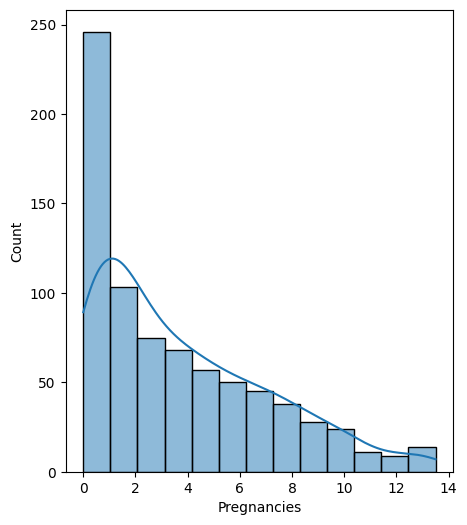

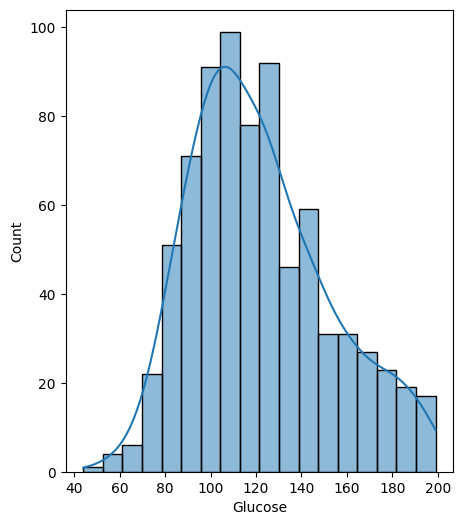

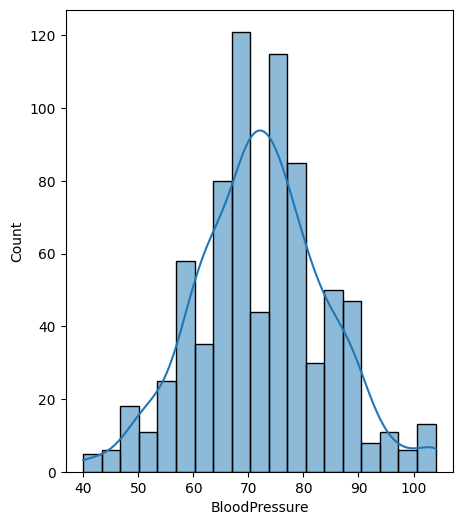

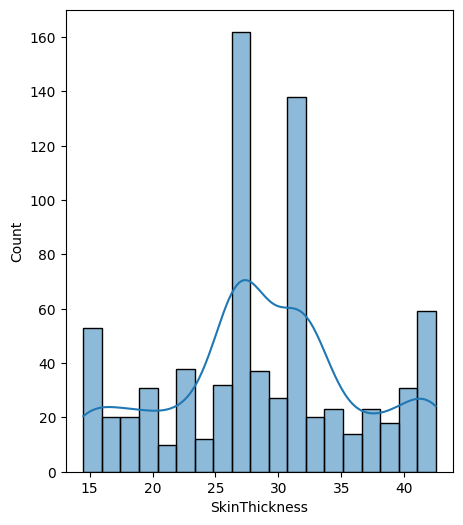

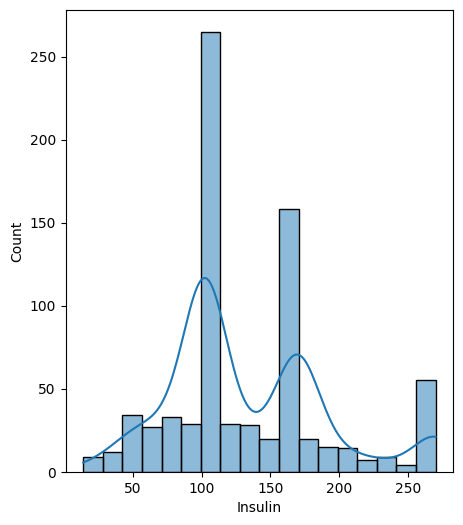

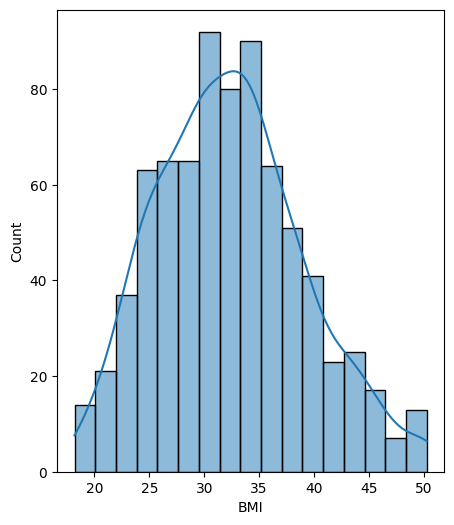

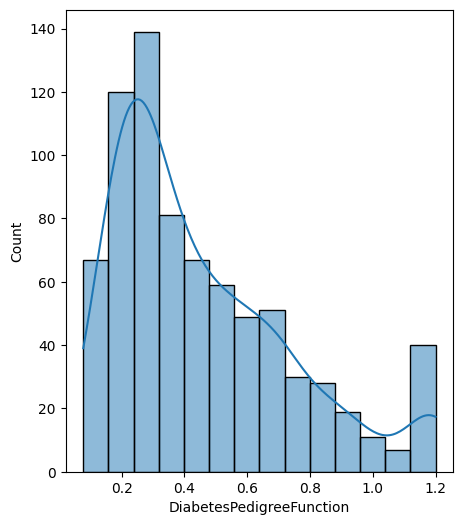

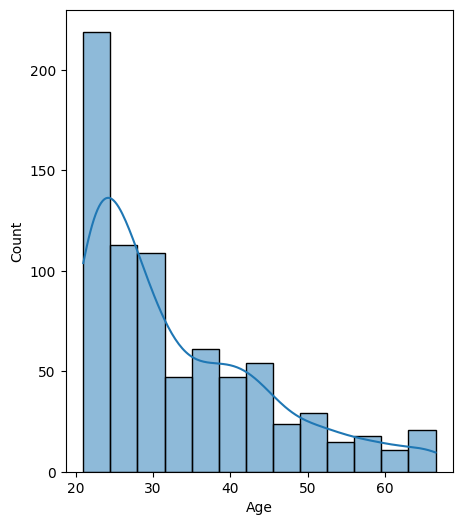

In [135]:
for i in numeric_cols:
    plt.figure(figsize=(5,6))
    sns.histplot(data=df_cleaned,x=i,kde=True)

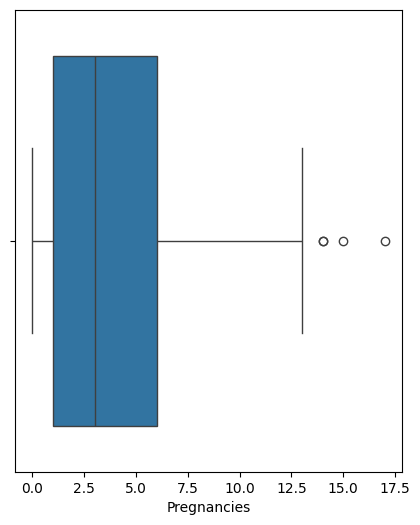

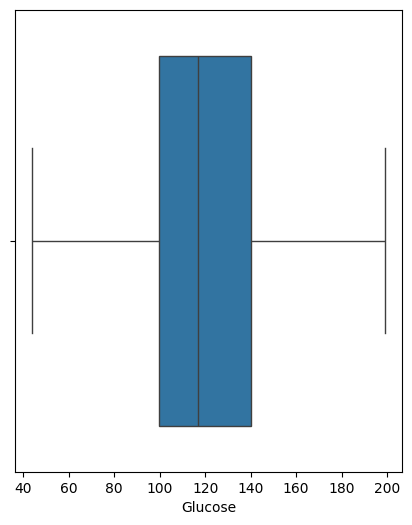

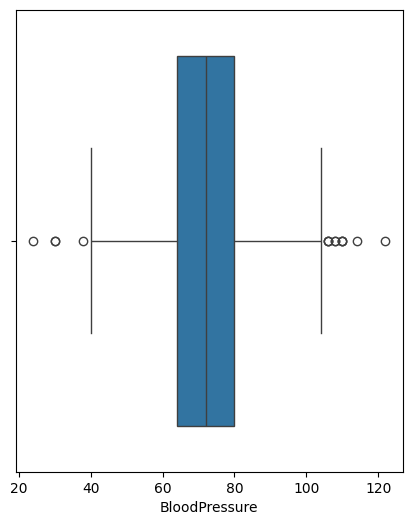

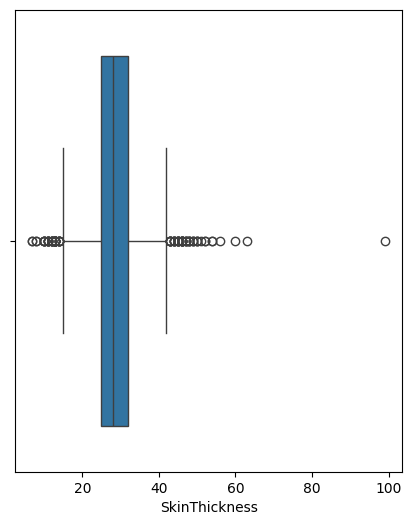

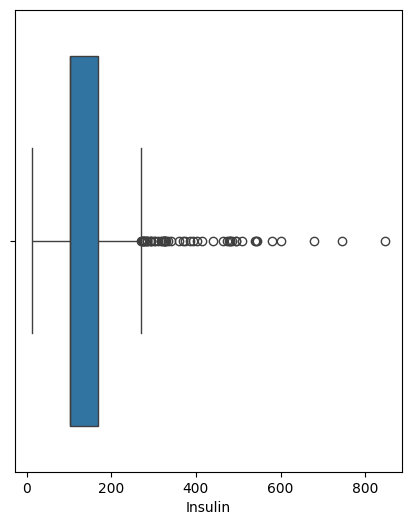

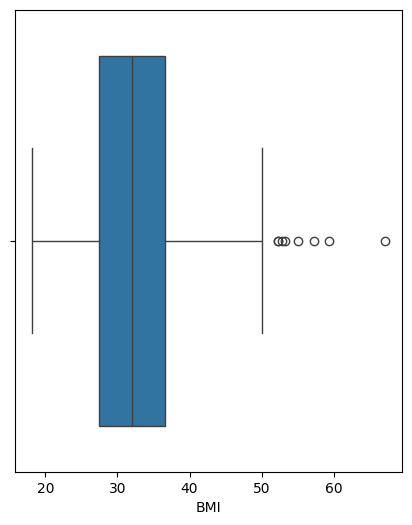

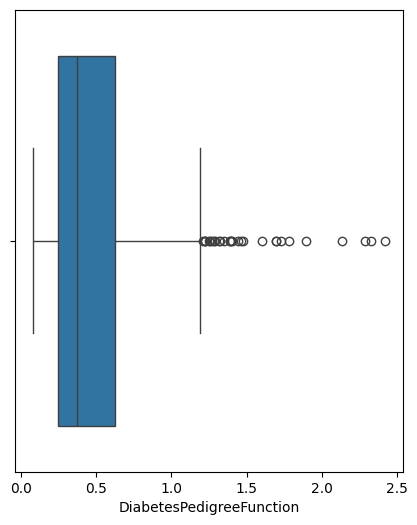

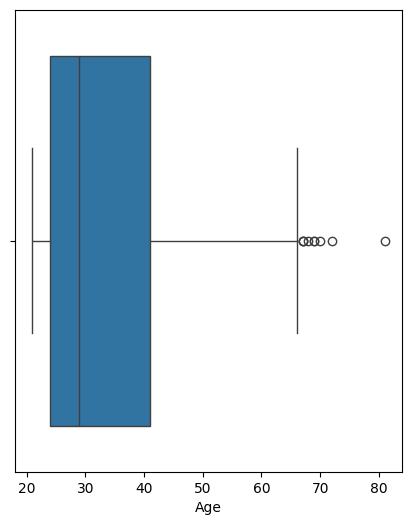

In [136]:
for i in numeric_col:
    plt.figure(figsize=(5,6))
    sns.boxplot(data=df,x=i)

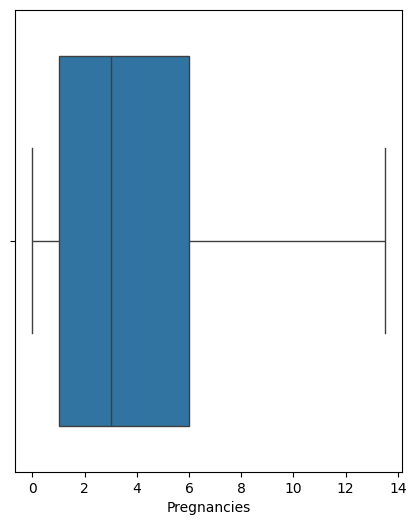

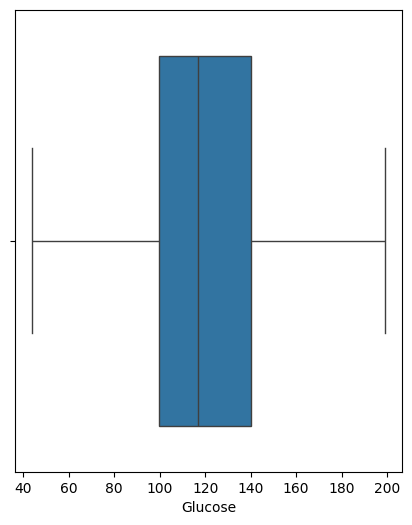

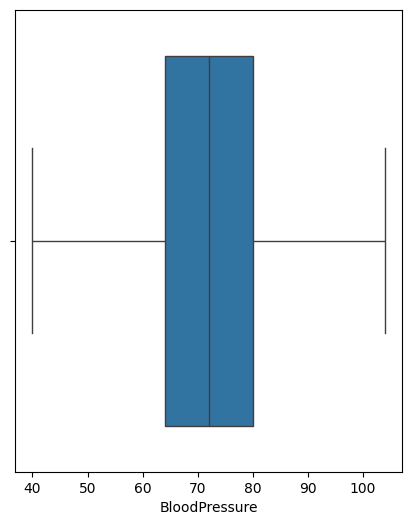

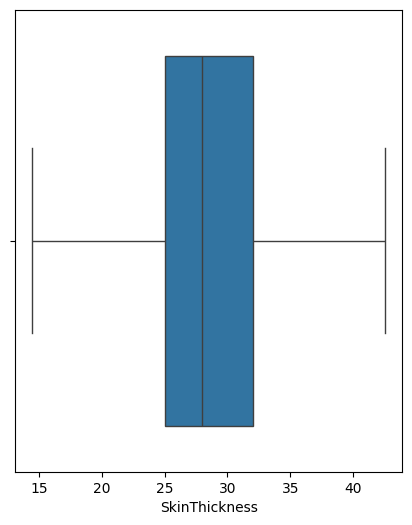

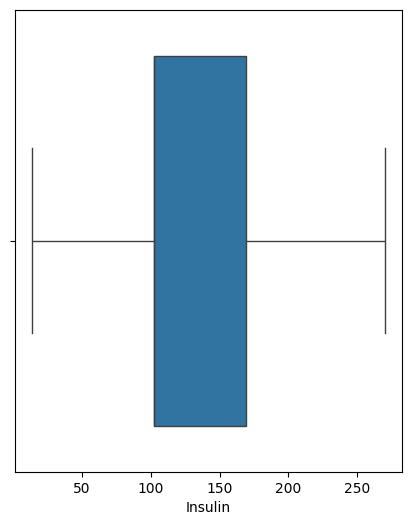

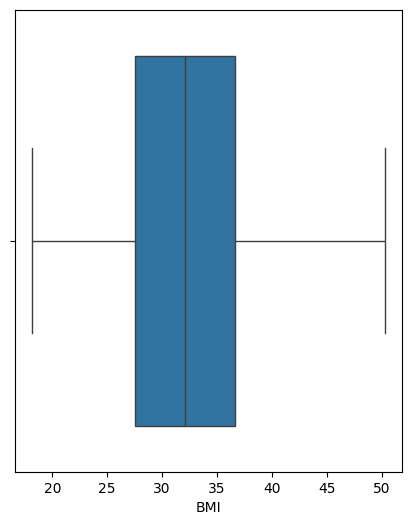

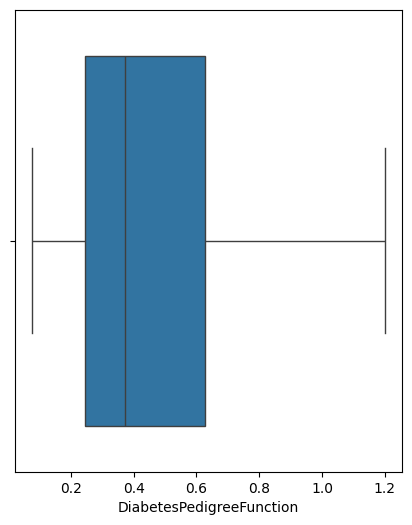

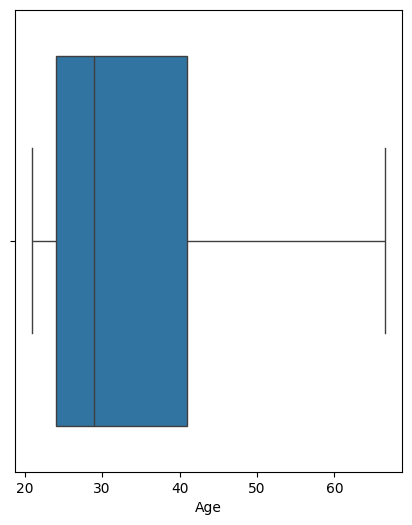

In [137]:
for i in numeric_col:
    plt.figure(figsize=(5,6))
    sns.boxplot(data=df_cleaned,x=i)

<Axes: >

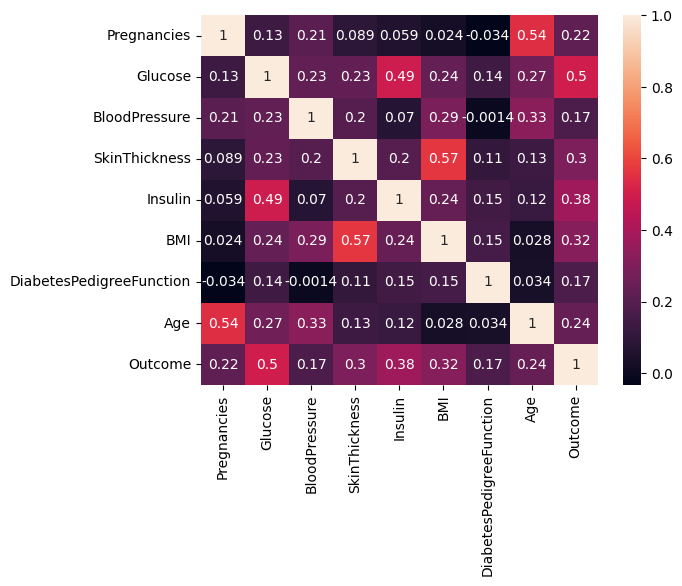

In [138]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [140]:
x = df_cleaned.drop('Outcome',axis=1)
y = df_cleaned['Outcome']

In [141]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [142]:
scaler=StandardScaler()

In [143]:

x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.fit_transform(X_test)

In [144]:
x_train_scaled.shape

(614, 8)

In [145]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


In [146]:
model_svm = SVC(probability=True)

In [147]:
model_svm.fit(x_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [148]:
model_pred = model_svm.predict(x_test_scaled)

In [149]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [150]:
acc =accuracy_score(y_test,model_pred)

In [151]:
acc

0.8636363636363636

In [152]:
f1 =f1_score(y_test,model_pred)

In [153]:
f1

0.8141592920353983

In [154]:
print(classification_report(y_test,model_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        99
           1       0.79      0.84      0.81        55

    accuracy                           0.86       154
   macro avg       0.85      0.86      0.85       154
weighted avg       0.87      0.86      0.86       154



In [155]:
print(confusion_matrix(y_test,model_pred))

[[87 12]
 [ 9 46]]


In [156]:
from sklearn.model_selection import GridSearchCV

In [157]:
parameters =[{'C':[1,10,100,1000],'kernel':['linear']},
    {'C':[1,10,100,1000],'kernel':['rbf'],'gamma':[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]}]
grid_search = GridSearchCV(  estimator=model_svm,
    param_grid=parameters,scoring='accuracy')


In [163]:
grid_search.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 10, ...], 'kernel': ['linear']}, {'C': [1, 10, ...], 'gamma': [0.1, 0.2, ...], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [164]:
acc = grid_search.best_score_

In [165]:
print(acc)

0.8551379448220711


In [166]:
input_data =(8,125,96,32,169.5,34.3,0.232,54)

input_data_num =np.asarray(input_data)

input_data_re = input_data_num.reshape(1, -1)

scaled_input = scaler.transform(input_data_re)

prediction = model_svm.predict(scaled_input)
print(prediction)
if prediction==1:
    print("You have  high Risk diabetes")
else:
    print('Low Risk of diabestes')

[1]
You have  high Risk diabetes


In [167]:
import joblib

joblib.dump(model_svm,'SVC_Dia2.pkl')
joblib.dump(scaler,'scaler_d2.pkl')
joblib.dump(x.columns.tolist(),'columns_d2.pkl')

['columns_d2.pkl']